# **Pronósticos basados en series de tiempo**

## - María del Carmen Sac
## - Juan Pablo Marroquín


##Ejercicio 2: Pronóstico de ocupados con *suavización_exponencial*



En esta segunda parte se busca encontrar el mejor modelo de pronóstico para la variable **Ocupados**, correspondiente al número de ocupados en miles de personas para las 13 principales ciudades.

En el ejercicio anterior evaluamos modelos de promedio móvil y encontramos que el mejor modelo fue **MA(14)**, con un RMSE de **215.79**. Sin embargo, los modelos de promedio móvil no incorporan explícitamente componentes de tendencia ni estacionalidad.

Por esta razón, en este ejercicio se evaluarán modelos de suavización exponencial simple, suavización de Holt y Holt-Winters, con el objetivo de comparar su desempeño y obtener el mejor pronóstico para los próximos 6 meses.

## **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se grafica la tasa de ocupación.



(222, 4)


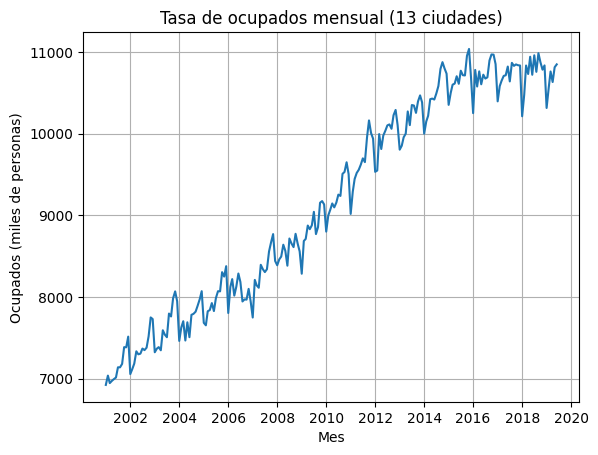

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de ocupados mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

## **3. División de la muestra**

Para evaluar la capacidad predictiva de los modelos, se dividirá la serie en una muestra de entrenamiento y una muestra de prueba.

Los últimos 6 meses serán utilizados como muestra de prueba, mientras que el resto de observaciones serán utilizadas para entrenar los modelos.

In [4]:
# últimos 6 meses para prueba
train_len = len(data) - 6

# Datos de entrenamiento
train_ocupados = data[["Ocupados"]][:train_len]

# Datos de prueba
test_ocupados = data[["Ocupados"]][train_len:]

# Tamaños
print(train_ocupados.shape)
print(test_ocupados.shape)

(216, 1)
(6, 1)


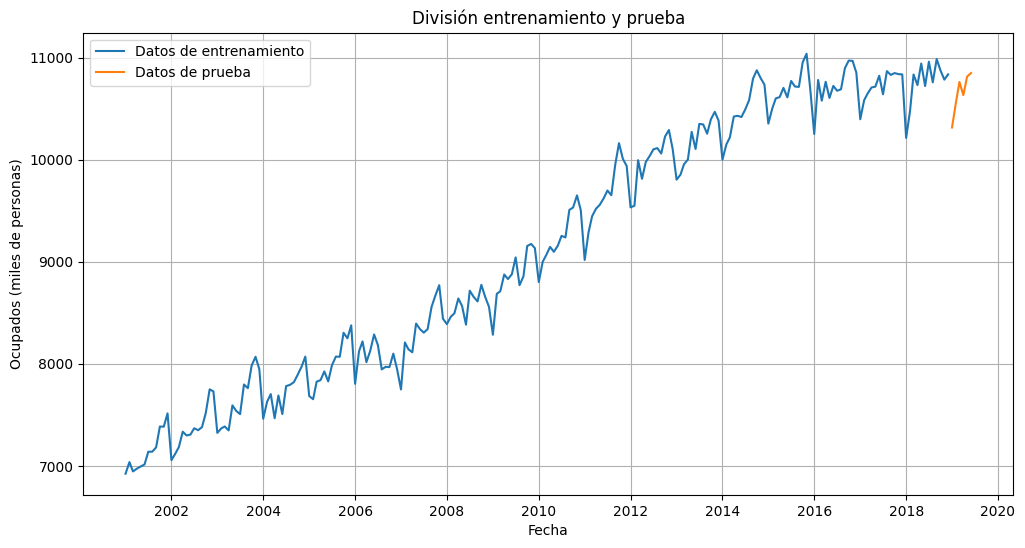

In [5]:
plt.figure(figsize=(12,6))

plt.plot(train_ocupados, label="Datos de entrenamiento")
plt.plot(test_ocupados, label="Datos de prueba")

plt.title("División entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

## **4. Suavizacion Exponencial Simple**

La suavización exponencial simple asigna mayor peso a las observaciones más recientes de la serie temporal.

Este método es adecuado cuando la serie no presenta tendencia ni estacionalidad marcada. En este ejercicio lo utilizaremos para comparar su desempeño frente a modelos más complejos como Holt y Holt-Winters.

## **Ejercicio:**  
*Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.*

En este caso los parámetros α, β y γ fueron estimados automáticamente por el modelo Holt-Winters aditivo.

El RMSE obtenido en la muestra de evaluación fue 74.44, siendo considerablemente menor que los modelos anteriores.

Esto indica que el modelo Holt-Winters aditivo logra capturar de manera adecuada tanto la tendencia como la estacionalidad presente en la serie de ocupados.

In [6]:
# Modelo de suavización exponencial simple

model_ses = ETSModel(
    endog=train_ocupados["Ocupados"],
    error="add"
)

# Ajustando el modelo
result_ses = model_ses.fit()

# Pronóstico
forecast_ses = result_ses.forecast(len(test_ocupados))

# RMSE
rmse_ses = np.sqrt(
    mean_squared_error(
        test_ocupados["Ocupados"],
        forecast_ses
    )
)

# Mostrando parámetros
print(result_ses.params)

# Mostrando RMSE
print("RMSE SES:", rmse_ses)

# Mostrando alpha
print("Alpha:", result_ses.params[0])

0       0.633732
1    6851.793132
dtype: float64
RMSE SES: 253.63725759469287
Alpha: 0.6337323614899885


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


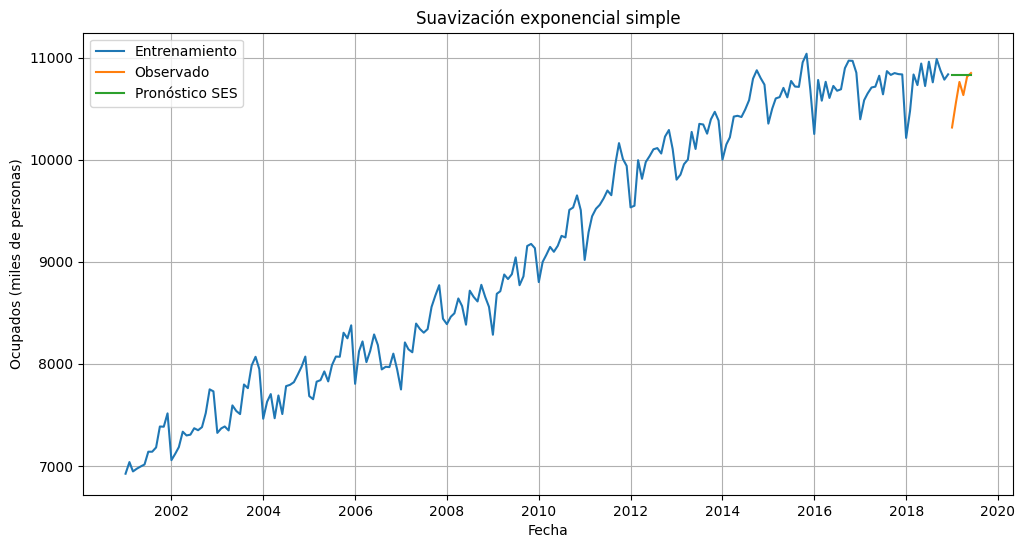

In [7]:
# Gráfica del modelo SES

plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train_ocupados, label="Entrenamiento")

# Datos observados
plt.plot(test_ocupados, label="Observado")

# Pronóstico SES
plt.plot(forecast_ses, label="Pronóstico SES")

plt.title("Suavización exponencial simple")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

En esta caso el α estimado es 0.6337. Y el RMSE en la muestra de evaluación es 253.64

## **5. Suavizacion Exponencial Lineal (Holt)**

El método de Holt extiende la suavización exponencial simple incorporando una componente de tendencia.

Este modelo resulta adecuado cuando la serie temporal presenta una tendencia creciente o decreciente, como ocurre con la serie de ocupados.

In [8]:
# Modelo Holt

model_holt = ETSModel(
    endog=train_ocupados["Ocupados"],
    error="add",
    trend="add"
)

# Ajustando el modelo
result_holt = model_holt.fit()

# Pronóstico
forecast_holt = result_holt.forecast(len(test_ocupados))

# RMSE
rmse_holt = np.sqrt(
    mean_squared_error(
        test_ocupados["Ocupados"],
        forecast_holt
    )
)

# Parámetros
print(result_holt.params)

# RMSE
print("RMSE Holt:", rmse_holt)

#parametros alpha y beta
print("Alpha:", result_holt.params[0],"Beta:", result_holt.params[1])

0       0.572583
1       0.006405
2    6851.793081
3      40.297728
dtype: float64
RMSE Holt: 296.15524441244435
Alpha: 0.5725831823098677 Beta: 0.006404915956342309


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


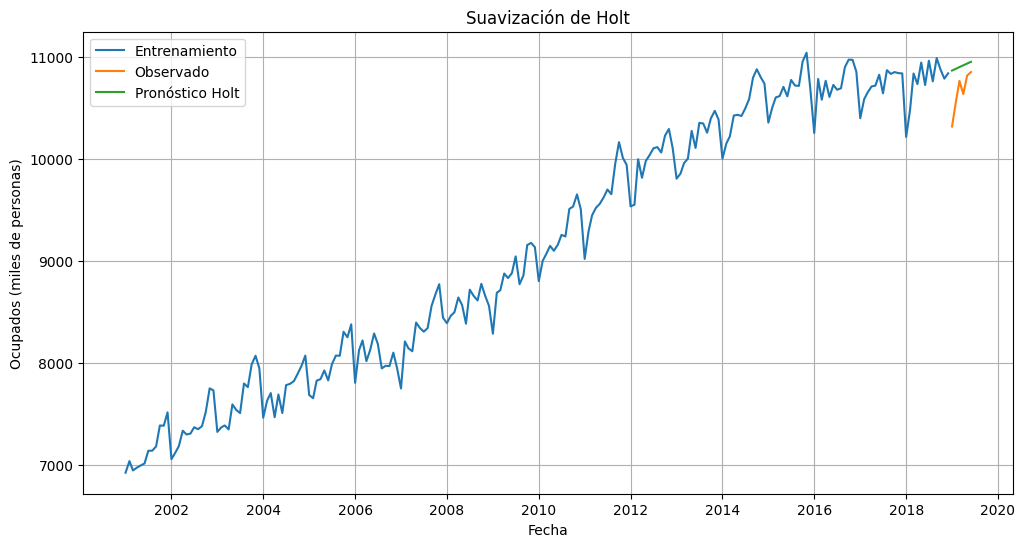

In [9]:
# Gráfica del modelo Holt

plt.figure(figsize=(12,6))

plt.plot(train_ocupados, label="Entrenamiento")
plt.plot(test_ocupados, label="Observado")
plt.plot(forecast_holt, label="Pronóstico Holt")

plt.title("Suavización de Holt")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

En esta caso el α estimado es  0.572583 y el β estimado es 0.006405. Y el RMSE en la muestra de evaluación es 296.15524441244435.

Aunque el modelo de Holt incorpora tendencia, en este caso presentó un RMSE mayor que el modelo de suavización exponencial simple y mayor que el modelo MA(14) del ejercicio anterior. Por lo tanto, hasta este punto no es el mejor modelo.

## **6. Suavizacion Exponencial Lineal de Winters (Holt-Winters) aditivo**


El modelo Holt-Winters aditivo incorpora componentes de nivel, tendencia y estacionalidad.

Este modelo es apropiado cuando la estacionalidad se mantiene relativamente constante a lo largo del tiempo.

In [10]:
# Modelo Holt-Winters aditivo

model_hw_add = ETSModel(
    endog=train_ocupados["Ocupados"],
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

# Ajustando modelo
result_hw_add = model_hw_add.fit()

# Pronóstico
forecast_hw_add = result_hw_add.forecast(len(test_ocupados))

# RMSE
rmse_hw_add = np.sqrt(
    mean_squared_error(
        test_ocupados["Ocupados"],
        forecast_hw_add
    )
)

# Parámetros
print(result_hw_add.params)

# RMSE
print("RMSE Holt-Winters aditivo:", rmse_hw_add)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


0        0.353227
1        0.000035
2        0.296946
3     7259.452163
4       17.352854
5        1.634714
6      -49.087025
7     -119.422871
8     -274.900337
9     -274.091120
10    -276.242953
11    -340.058677
12    -283.802543
13    -317.337277
14    -311.725461
15    -288.836990
16       0.000000
dtype: float64
RMSE Holt-Winters aditivo: 74.44457717563775


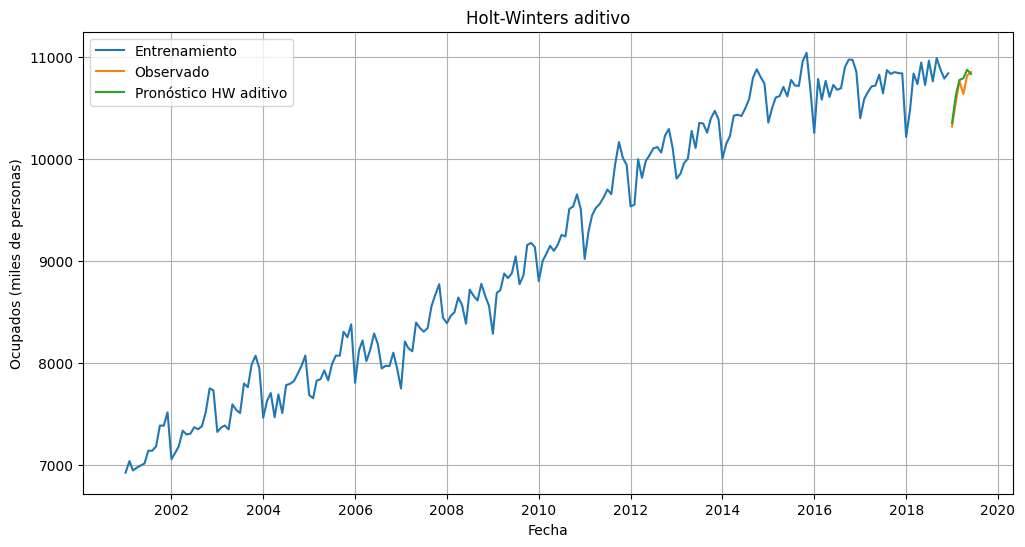

In [11]:
# Gráfica Holt-Winters aditivo

plt.figure(figsize=(12,6))

plt.plot(train_ocupados, label="Entrenamiento")
plt.plot(test_ocupados, label="Observado")
plt.plot(forecast_hw_add, label="Pronóstico HW aditivo")

plt.title("Holt-Winters aditivo")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

En este caso los parámetros α, β y γ fueron estimados automáticamente por el modelo Holt-Winters aditivo.

El RMSE obtenido en la muestra de evaluación fue 74.44, siendo considerablemente menor que los modelos anteriores.

Esto indica que el modelo Holt-Winters aditivo logra capturar de manera adecuada tanto la tendencia como la estacionalidad presente en la serie de ocupados.

## **6. Suavizacion Exponencial Lineal de Winters (Holt-Winters) multiplicativo**

El modelo Holt-Winters multiplicativo también incorpora nivel, tendencia y estacionalidad.

Este modelo es útil cuando la estacionalidad cambia de forma proporcional al nivel de la serie.

In [12]:
# Modelo Holt-Winters multiplicativo

model_hw_mul = ETSModel(
    endog=train_ocupados["Ocupados"],
    error="add",
    trend="add",
    seasonal="mul",
    seasonal_periods=12
)

# Ajustando modelo
result_hw_mul = model_hw_mul.fit()

# Pronóstico
forecast_hw_mul = result_hw_mul.forecast(len(test_ocupados))

# RMSE
rmse_hw_mul = np.sqrt(
    mean_squared_error(
        test_ocupados["Ocupados"],
        forecast_hw_mul
    )
)

# Parámetros
print(result_hw_mul.params)

# RMSE
print("RMSE Holt-Winters multiplicativo:", rmse_hw_mul)

# Alpha, Beta y Gamma
print("Alpha:", result_hw_mul.params[0], "Beta:", result_hw_mul.params[1], "Gamma:", result_hw_mul.params[2])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


0        0.524339
1        0.001805
2        0.000048
3     7112.283534
4       20.676470
5        1.044895
6        1.055686
7        1.055075
8        1.043306
9        1.036163
10       1.039002
11       1.030602
12       1.034852
13       1.028243
14       1.027309
15       1.019229
16       1.000000
dtype: float64
RMSE Holt-Winters multiplicativo: 59.63433929940899
Alpha: 0.5243386266245855 Beta: 0.0018054725128846055 Gamma: 4.756613733754145e-05


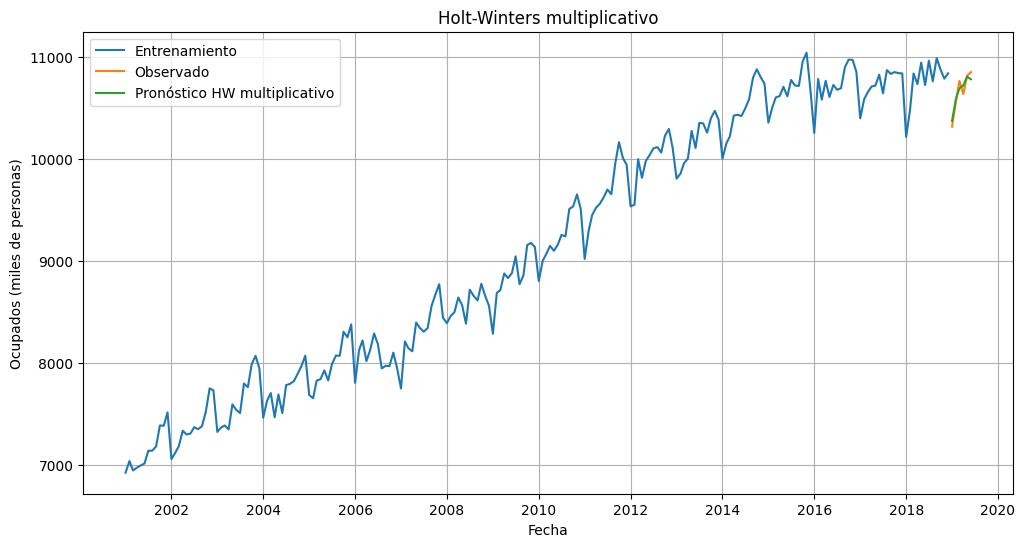

In [13]:
# Gráfica Holt-Winters multiplicativo

plt.figure(figsize=(12,6))

plt.plot(train_ocupados, label="Entrenamiento")
plt.plot(test_ocupados, label="Observado")
plt.plot(forecast_hw_mul, label="Pronóstico HW multiplicativo")

plt.title("Holt-Winters multiplicativo")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

En este caso los parámetros α, β y γ fueron estimados automáticamente por el modelo Holt-Winters multiplicativo. (α: 0.5243386266245855, β: 0.0018054725128846055, y γ: 4.756613733754145e-05.)

El RMSE obtenido en la muestra de evaluación fue 59.63, siendo el menor entre todos los modelos evaluados.

Esto indica que el modelo Holt-Winters multiplicativo logra capturar adecuadamente tanto la tendencia como la estacionalidad proporcional presente en la serie de ocupados, por lo que se selecciona como el mejor modelo.

## **7. Comparación de modelos**

Para seleccionar el mejor modelo comparamos los valores de RMSE obtenidos para cada metodología.

También incluímos el resultado obtenido en el ejercicio anterior con el modelo MA(14), con el fin de evaluar si los métodos de suavización exponencial mejoran la capacidad predictiva.

In [14]:
# Tabla comparativa de modelos

resultados = pd.DataFrame({
    "Modelo": [
        "MA(14)",
        "Suavización exponencial simple",
        "Holt",
        "Holt-Winters aditivo",
        "Holt-Winters multiplicativo"
    ],
    "RMSE": [
        215.79,
        rmse_ses,
        rmse_holt,
        rmse_hw_add,
        rmse_hw_mul
    ]
})

resultados

,Modelo,RMSE
0,MA(14),215.790000
1,Suavización exponencial simple,253.637258
2,Holt,296.155244
3,Holt-Winters aditivo,74.444577
4,Holt-Winters multiplicativo,59.634339


El modelo Holt-Winters multiplicativo presentó el menor RMSE entre todos los modelos evaluados.

Esto sugiere que la serie de ocupados presenta componentes de tendencia y estacionalidad proporcional que son capturados adecuadamente por este modelo.

Por esta razón, utilizaremos el modelo Holt-Winters multiplicativo para generar los pronósticos de los próximos 6 meses.

## **8. Pronóstico para los próximos 6 meses**



In [15]:
# Modelo final usando toda la serie

# Recuperando los parámetros alpha, beta y gamma del modelo Holt-Winters multiplicativo (punto 6)
# (Estos serán usados como parámetros iniciales para la optimización)

final_model = ETSModel(
    endog=data["Ocupados"],
    error="add",
    trend="add",
    seasonal="mul",
    seasonal_periods=12
)

# Ajustando modelo final, usando los parámetros del modelo de Holt-Winters multiplicativo como valores iniciales
final_result = final_model.fit(initial_params=result_hw_mul.params, disp=False) # disp=False para evitar la impresión de la tabla de resumen

# Pronóstico próximos 6 meses
forecast_6 = final_result.forecast(6)

# Mostrando pronósticos
forecast_6

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: initial_params. After release 0.14, this will raise.
  warnings.warn(


,simulation
2019-07-01,10915.496926
2019-08-01,10903.946597
2019-09-01,10997.498215
2019-10-01,11140.191635
2019-11-01,11165.265876
2019-12-01,11069.602867


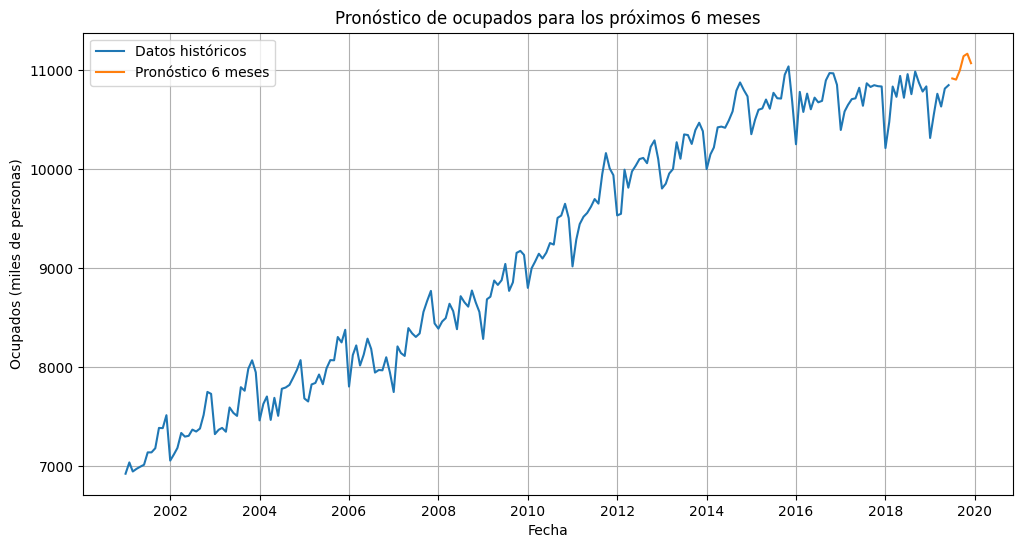

In [16]:
# Gráfica del pronóstico final

plt.figure(figsize=(12,6))

plt.plot(data["Ocupados"], label="Datos históricos")
plt.plot(forecast_6, label="Pronóstico 6 meses")

plt.title("Pronóstico de ocupados para los próximos 6 meses")
plt.xlabel("Fecha")
plt.ylabel("Ocupados (miles de personas)")

plt.legend()
plt.grid()
plt.show()

El modelo Holt-Winters multiplicativo pronostica que el número de ocupados se mantendrá alrededor de 10.900 a 11.165 miles de personas durante los próximos 6 meses.

El valor más alto se proyecta para noviembre de 2019, mientras que el valor más bajo se proyecta para agosto de 2019.

## **Conclusiones**

Comparamos diferentes modelos de suavización exponencial para pronosticar la serie de ocupados en las 13 principales ciudades de Colombia.

Los resultados mostraron que el modelo Holt-Winters multiplicativo presentó el menor RMSE (59.63), superando tanto los modelos de suavización exponencial simple y Holt como el modelo MA(14) obtenido en el ejercicio anterior.

Lo que indica que la serie presenta componentes importantes de tendencia y estacionalidad proporcional, las cuales son capturadas adecuadamente por el modelo Holt-Winters multiplicativo.

Finalmente, utilizando este modelo realizamos los pronósticos para los próximos 6 meses, obteniendos que el número de ocupados se mantendrá relativamente estable, oscilando entre aproximadamente 10.900 y 11.165 miles de personas. El valor más alto proyectado se estima para noviembre de 2019, mientras que el valor más bajo para agosto de 2019.

## **Limitaciones**

Los pronósticos realizados dependen del comportamiento histórico observado en la serie temporal. Esto implica que el modelo asume que las tendencias y patrones estacionales continuarán de manera similar en el futuro.

Sin embargo, factores externos como cambios económicos, políticas laborales, inflación, crisis financieras o eventos inesperados pueden modificar el comportamiento real del número de ocupados.

Por esta razón, los resultados deben interpretarse como aproximaciones estadísticas y no como valores exactos.